# Lab 16: Transfer Learning và Data Augmentation

## PHẦN 1: CÀI ĐẶT MÔI TRƯỜNG (15 phút)

### Bước 1: Thiết lập Google Colab

In [1]:
# Kiểm tra GPU
!nvidia-smi

Mon Sep 21 06:58:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Cài đặt thư viện cần thiết
!pip install imutils

In [3]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imutils import paths
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import shutil
from PIL import Image
import requests
import tarfile

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Bước 2: Tải và tổ chức dataset

In [4]:
import os
import shutil
import requests
import tarfile
from pathlib import Path

# Bước 2: Tải và tổ chức Oxford Flowers-17 dataset
def download_and_organize_flowers17():
    # URL của Oxford Flowers-17 dataset
    dataset_url = "http://www.robots.ox.ac.uk/~vgg/data/flowers/17/17flowers.tgz"

    # Tải dataset nếu chưa có
    if not os.path.exists("17flowers.tgz"):
        print("Đang tải Oxford Flowers-17 dataset...")
        response = requests.get(dataset_url, stream=True)
        with open("17flowers.tgz", "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Tải hoàn tất!")

    # Giải nén dataset
    if not os.path.exists("jpg"):
        print("Đang giải nén dataset...")
        with tarfile.open("17flowers.tgz", "r:gz") as tar:
            tar.extractall()
        print("Giải nén hoàn tất!")

    # Tạo cấu trúc thư mục cho dataset
    dataset_path = Path("dataset")
    dataset_path.mkdir(exist_ok=True)

    # Danh sách tên các loài hoa theo thứ tự trong dataset
    flower_names = [
        'daffodil', 'snowdrop', 'lilyvalley', 'bluebell', 'crocus',
        'iris', 'tigerlily', 'tulip', 'fritillary', 'sunflower',
        'daisy', 'coltsfoot', 'dandelion', 'cowslip', 'buttercup',
        'windflower', 'pansy'
    ]

    # Tạo thư mục cho mỗi loài hoa
    for flower in flower_names:
        (dataset_path / flower).mkdir(exist_ok=True)

    # Tổ chức ảnh theo class (mỗi class có 80 ảnh)
    jpg_path = Path("jpg")
    if jpg_path.exists():
        # Lấy tất cả file ảnh và sắp xếp theo tên
        jpg_files = sorted([f for f in jpg_path.glob("*.jpg")])

        print(f"Tìm thấy {len(jpg_files)} ảnh")

        # Di chuyển ảnh vào thư mục tương ứng
        for i, img_file in enumerate(jpg_files):
            class_idx = i // 80  # Mỗi class có 80 ảnh
            if class_idx < len(flower_names):
                flower_name = flower_names[class_idx]
                dst_path = dataset_path / flower_name / img_file.name

                # Copy file thay vì move để tránh lỗi
                shutil.copy2(str(img_file), str(dst_path))

        print(f"Đã tổ chức {len(jpg_files)} ảnh vào {len(flower_names)} classes")
    else:
        print("Không tìm thấy thư mục 'jpg'. Kiểm tra lại việc giải nén.")

    return flower_names

# Chạy function để tải và tổ chức dataset
flower_names = download_and_organize_flowers17()

# Kiểm tra kết quả
print("\nKiểm tra dataset:")
for flower in flower_names:
    count = len(list(Path(f"dataset/{flower}").glob("*.jpg")))
    print(f"{flower}: {count} ảnh")

# Tổng số ảnh
total_images = sum(len(list(Path(f"dataset/{flower}").glob("*.jpg"))) for flower in flower_names)
print(f"\nTổng số ảnh: {total_images}")


Đang tải Oxford Flowers-17 dataset...
Tải hoàn tất!
Đang giải nén dataset...


/tmp/ipykernel_681/489838677.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Giải nén hoàn tất!
Tìm thấy 1360 ảnh
Đã tổ chức 1360 ảnh vào 17 classes

Kiểm tra dataset:
daffodil: 80 ảnh
snowdrop: 80 ảnh
lilyvalley: 80 ảnh
bluebell: 80 ảnh
crocus: 80 ảnh
iris: 80 ảnh
tigerlily: 80 ảnh
tulip: 80 ảnh
fritillary: 80 ảnh
sunflower: 80 ảnh
daisy: 80 ảnh
coltsfoot: 80 ảnh
dandelion: 80 ảnh
cowslip: 80 ảnh
buttercup: 80 ảnh
windflower: 80 ảnh
pansy: 80 ảnh

Tổng số ảnh: 1360


## PHẦN 2: FEATURE EXTRACTOR (45 phút)

### Bước 1: Chuẩn bị dữ liệu

In [5]:
# Lấy đường dẫn ảnh
image_paths = list(paths.list_images('dataset/'))
random.shuffle(image_paths)

# Trích xuất labels từ đường dẫn
labels = [p.split(os.path.sep)[-2] for p in image_paths]

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)

print(f"Số lượng ảnh: {len(image_paths)}")
print(f"Số lượng classes: {len(np.unique(labels))}")
print(f"Classes: {le.classes_}")


Số lượng ảnh: 1360
Số lượng classes: 17
Classes: ['bluebell' 'buttercup' 'coltsfoot' 'cowslip' 'crocus' 'daffodil' 'daisy'
 'dandelion' 'fritillary' 'iris' 'lilyvalley' 'pansy' 'snowdrop'
 'sunflower' 'tigerlily' 'tulip' 'windflower']


### Bước 2: Load pre-trained VGG16

In [6]:
# Load VGG16 không bao gồm top layers
print("[INFO] Loading VGG16...")
model = VGG16(weights='imagenet', include_top=False)

# Hiển thị kiến trúc
model.summary()


[INFO] Loading VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, None, None, 64) │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, None, None,     │        73,856 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, None, None,     │       147,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, None, None,     │       295,168 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, None, None,     │       590,080 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, None, None,     │     1,180,160 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, None, None,     │             0 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, None, None,     │     2,359,808 │
│                                 │ 512)                   │             

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Bước 3: Trích xuất features

In [7]:
# Function để load và preprocess ảnh
def load_and_preprocess_image(image_path):
    image = load_img(image_path, target_size=(224, 224))
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    image = imagenet_utils.preprocess_input(image)
    return image

# Trích xuất features từ tất cả ảnh
print("[INFO] Extracting features...")
features = []

for (i, image_path) in enumerate(image_paths):
    if i % 100 == 0:
        print(f"Processed {i}/{len(image_paths)} images")

    image = load_and_preprocess_image(image_path)
    feature = model.predict(image, verbose=0)
    features.append(feature)

# Chuyển đổi thành numpy array và flatten
features = np.array(features)
features = features.reshape((features.shape[0], 7 * 7 * 512))

print(f"Features shape: {features.shape}")


[INFO] Extracting features...
Processed 0/1360 images
Processed 100/1360 images
Processed 200/1360 images
Processed 300/1360 images
Processed 400/1360 images
Processed 500/1360 images
Processed 600/1360 images
Processed 700/1360 images
Processed 800/1360 images
Processed 900/1360 images
Processed 1000/1360 images
Processed 1100/1360 images
Processed 1200/1360 images
Processed 1300/1360 images
Features shape: (1360, 25088)


### Bước 4: Train classifier

In [8]:
# Chia train/test cho FEATURE EXTRACTOR
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels
)

print("[INFO] Training classifier (Feature Extractor)...")
params = {'C': [0.1, 1.0, 10.0, 100.0]}
model_lr = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=3)
model_lr.fit(X_train_fe, y_train_fe)

print(f"Best parameters: {model_lr.best_params_}")

# Đánh giá FE trên test set của FE
predictions_fe = model_lr.predict(X_test_fe)
print("\n[RESULTS] Feature Extractor:")
print(classification_report(y_test_fe, predictions_fe, target_names=le.classes_))


[INFO] Training classifier (Feature Extractor)...
Best parameters: {'C': 0.1}

[RESULTS] Feature Extractor:
              precision    recall  f1-score   support

    bluebell       0.88      0.94      0.91        16
   buttercup       0.94      0.94      0.94        16
   coltsfoot       1.00      0.94      0.97        16
     cowslip       0.81      0.81      0.81        16
      crocus       0.89      1.00      0.94        16
    daffodil       0.88      0.88      0.88        16
       daisy       0.88      0.94      0.91        16
   dandelion       0.94      0.94      0.94        16
  fritillary       0.94      1.00      0.97        16
        iris       1.00      0.75      0.86        16
  lilyvalley       0.93      0.88      0.90        16
       pansy       0.93      0.88      0.90        16
    snowdrop       0.83      0.94      0.88        16
   sunflower       0.94      0.94      0.94        16
   tigerlily       1.00      1.00      1.00        16
       tulip       0.93    

## PHẦN 3: FINE TUNING (60 phút)

### Bước 1: Chuẩn bị dữ liệu cho Deep Learning

In [9]:
# Load lại ảnh (không extract features)
def load_images_and_labels():
    images = []
    labels = []

    for image_path in image_paths:
        # Load ảnh
        image = load_img(image_path, target_size=(224, 224))
        image = img_to_array(image)
        image = imagenet_utils.preprocess_input(image)

        # Extract label
        label = image_path.split(os.path.sep)[-2]

        images.append(image)
        labels.append(label)

    return np.array(images), labels

print("[INFO] Loading images for fine-tuning...")
images, label_names = load_images_and_labels()

# Encode labels cho fine-tuning
le_ft = LabelEncoder()
labels_encoded = le_ft.fit_transform(label_names)

# One-hot encoding
lb = LabelBinarizer()
labels_onehot = lb.fit_transform(labels_encoded)

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels_onehot.shape}")


[INFO] Loading images for fine-tuning...
Images shape: (1360, 224, 224, 3)
Labels shape: (1360, 17)


### Bước 2: Xây dựng model Fine Tuning

In [10]:
# Load VGG16 với input tensor
base_model = VGG16(weights='imagenet', include_top=False,
                   input_tensor=Input(shape=(224, 224, 3)))

# Thêm classification head
head_model = base_model.output
head_model = Flatten(name="flatten")(head_model)
head_model = Dense(256, activation="relu")(head_model)
head_model = Dropout(0.5)(head_model)
head_model = Dense(len(le_ft.classes_), activation="softmax")(head_model)

# Tạo model hoàn chỉnh
model_ft = Model(inputs=base_model.input, outputs=head_model)

print(f"Total layers: {len(model_ft.layers)}")
print(f"Base model layers: {len(base_model.layers)}")


Total layers: 23
Base model layers: 19


### Bước 3: Chia dữ liệu và setup augmentation

In [11]:
# Chia train/test cho FINE-TUNING
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    images, labels_onehot, test_size=0.2, random_state=42
)

print(f"Training set: {X_train_ft.shape}")
print(f"Test set: {X_test_ft.shape}")
# Data augmentation
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_aug = ImageDataGenerator(rescale=1./255)

print(f"Training set: {X_train_ft.shape}")
print(f"Test set: {X_test_ft.shape}")


Training set: (1088, 224, 224, 3)
Test set: (272, 224, 224, 3)
Training set: (1088, 224, 224, 3)
Test set: (272, 224, 224, 3)


### Bước 4: Phase 1 - Warm up head

In [12]:
# Phase 1: Freeze base model
print("[INFO] Phase 1: Training head only...")
for layer in base_model.layers:
    layer.trainable = False

# Compile model
opt = RMSprop(learning_rate=0.001)
model_ft.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

# Train
EPOCHS_PHASE1 = 25
history1 = model_ft.fit(
    train_aug.flow(X_train_ft, y_train_ft, batch_size=32),
    steps_per_epoch=len(X_train_ft) // 32,
    validation_data=test_aug.flow(X_test_ft, y_test_ft, batch_size=32),
    validation_steps=len(X_test_ft) // 32,
    epochs=EPOCHS_PHASE1,
    verbose=1
)


[INFO] Phase 1: Training head only...
Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 494ms/step - accuracy: 0.1728 - loss: 4.0862 - val_accuracy: 0.4727 - val_loss: 1.9001
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 25s 475ms/step - accuracy: 0.3088 - loss: 2.2047 - val_accuracy: 0.5078 - val_loss: 1.5579
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 502ms/step - accuracy: 0.3649 - loss: 1.9627 - val_accuracy: 0.6133 - val_loss: 1.2298
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step - accuracy: 0.4651 - loss: 1.6596 - val_accuracy: 0.6680 - val_loss: 1.0487
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 480ms/step - accuracy: 0.5055 - loss: 1.5270 - val_accuracy: 0.7422 - val_loss: 0.9093
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 496ms/step - accuracy: 0.5358 - loss: 1.4110 - val_accuracy: 0.6953 - val_loss: 0.9316
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 474ms/step - accuracy: 0.6048 - loss: 1.2764 - val_accuracy: 0.7969 - val_loss: 0.7378
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 473ms/step - accu

### Bước 5: Phase 2 - Fine tune

In [16]:
import tensorflow as tf
from tensorflow.keras.optimizers import SGD
# Phase 2: Unfreeze và fine-tune
print("[INFO] Phase 2: Fine-tuning...")

# Unfreeze một số layers cuối
for layer in base_model.layers[15:]:
    layer.trainable = True

# Compile lại với learning rate thấp hơn
opt = SGD(learning_rate=0.001/10)
model_ft.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])

# Continue training
EPOCHS_PHASE2 = 25
history2 = model_ft.fit(
    train_aug.flow(X_train_ft, y_train_ft, batch_size=32),
    steps_per_epoch=len(X_train_ft) // 32,
    validation_data=test_aug.flow(X_test_ft, y_test_ft, batch_size=32),
    validation_steps=len(X_test_ft) // 32,
    epochs=EPOCHS_PHASE2,
    verbose=1
)


[INFO] Phase 2: Fine-tuning...
Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 550ms/step - accuracy: 0.8107 - loss: 0.5757 - val_accuracy: 0.9023 - val_loss: 0.3623
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 32s 493ms/step - accuracy: 0.7996 - loss: 0.5494 - val_accuracy: 0.9062 - val_loss: 0.3468
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 496ms/step - accuracy: 0.8116 - loss: 0.5392 - val_accuracy: 0.9180 - val_loss: 0.3280
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.8116 - loss: 0.5118 - val_accuracy: 0.9180 - val_loss: 0.3393
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 483ms/step - accuracy: 0.8199 - loss: 0.5111 - val_accuracy: 0.9141 - val_loss: 0.3412
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 487ms/step - accuracy: 0.8189 - loss: 0.5008 - val_accuracy: 0.9180 - val_loss: 0.3252
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 511ms/step - accuracy: 0.8226 - loss: 0.4932 - val_accuracy: 0.9219 - val_loss: 0.3010
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 508ms/step - accuracy: 0

## PHẦN 4: SO SÁNH VÀ ĐÁNH GIÁ (30 phút)

### Bước 1: Vẽ learning curves

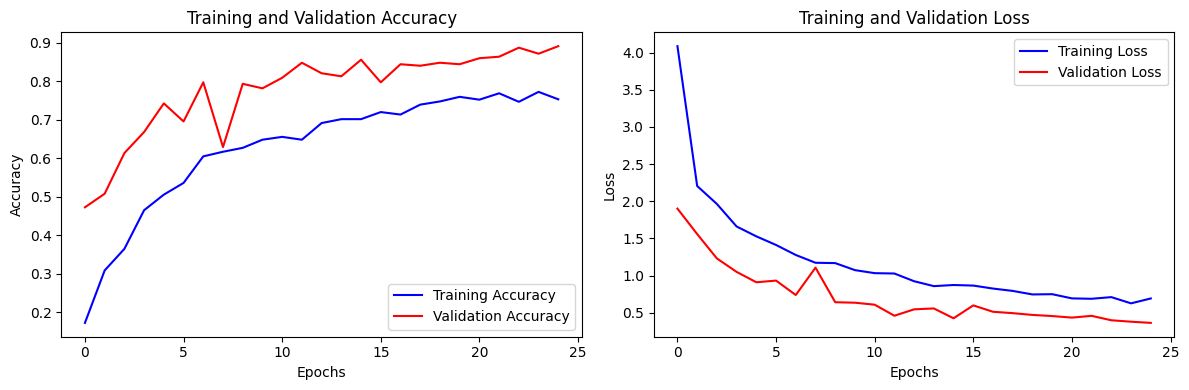

In [17]:

def plot_training_history(history1):
    # Combine histories - only use history1 for now
    acc = history1.history['accuracy']
    val_acc = history1.history['val_accuracy']
    loss = history1.history['loss']
    val_loss = history1.history['val_loss']

    epochs = range(len(acc))

    # Plot
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    # Remove the line indicating fine-tune start as it's not applicable with only one history
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    # Remove the line indicating fine-tune start as it's not applicable with only one history
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history1)


### Bước 2: Đánh giá final model

[INFO] Evaluating fine-tuned model...
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step

[RESULTS] Fine Tuning:
              precision    recall  f1-score   support

    bluebell       0.86      0.90      0.88        20
   buttercup       1.00      0.94      0.97        16
   coltsfoot       1.00      0.93      0.96        14
     cowslip       0.92      0.80      0.86        15
      crocus       0.71      0.94      0.81        18
    daffodil       0.93      1.00      0.97        14
       daisy       1.00      1.00      1.00        18
   dandelion       1.00      1.00      1.00        12
  fritillary       0.94      1.00      0.97        17
        iris       1.00      0.89      0.94        18
  lilyvalley       0.94      0.88      0.91        17
       pansy       1.00      0.73      0.84        11
    snowdrop       0.89      0.77      0.83        22
   sunflower       1.00      1.00      1.00        16
   tigerlily       0.88      1.00      0.94        15
       tulip       0.67      0.83   

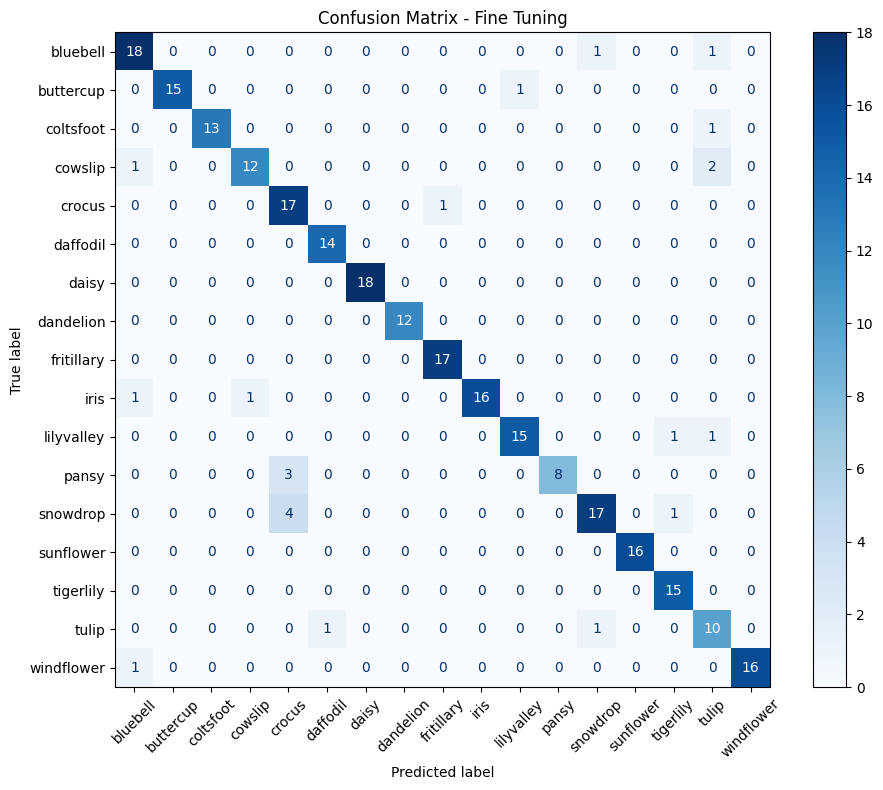

In [18]:
# Predict trên test set
print("[INFO] Evaluating fine-tuned model...")
predictions = model_ft.predict(test_aug.flow(X_test_ft, y_test_ft, batch_size=32, shuffle=False))
predictions = np.argmax(predictions, axis=1)
y_test_labels = np.argmax(y_test_ft, axis=1)

# Classification report
print("\n[RESULTS] Fine Tuning:")
print(classification_report(y_test_labels, predictions, target_names=le_ft.classes_))

# Confusion matrix
cm = confusion_matrix(y_test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_ft.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Fine Tuning")
plt.tight_layout()
plt.show()


### Bước 3: So sánh kết quả

In [19]:
# ===== Bước 3 (đÃ SỬA): So sánh kết quả =====
from math import ceil

print("[INFO] Đang so sánh kết quả giữa Feature Extractor và Fine Tuning...")

# 1) Accuracy của FEATURE EXTRACTOR trên test set FE
fe_accuracy = model_lr.score(X_test_fe, y_test_fe)

# 2) Accuracy của FINE-TUNING trên test set FT
#   - Dùng generator với rescale giống lúc validation
test_ft_gen = test_aug.flow(X_test_ft, y_test_ft, batch_size=32, shuffle=False)

#   - Tránh steps=0 khi test ít mẫu
steps = max(1, len(X_test_ft) // 32)
ft_eval = model_ft.evaluate(test_ft_gen, steps=steps, verbose=0)
ft_accuracy = ft_eval[1]  # metrics=["accuracy"] => index 1

# 3) In bảng so sánh
print("\n" + "="*50)
print("BẢNG SO SÁNH KẾT QUẢ (đánh giá trên TEST của từng pipeline)")
print("="*50)
print(f"Feature Extractor Accuracy (test FE): {fe_accuracy:.4f}")
print(f"Fine Tuning Accuracy (test FT):       {ft_accuracy:.4f}")
print(f"Improvement (FT - FE):                {ft_accuracy - fe_accuracy:+.4f}")
print("="*50)


[INFO] Đang so sánh kết quả giữa Feature Extractor và Fine Tuning...

BẢNG SO SÁNH KẾT QUẢ (đánh giá trên TEST của từng pipeline)
Feature Extractor Accuracy (test FE): 0.9154
Fine Tuning Accuracy (test FT):       0.9102
Improvement (FT - FE):                -0.0053


## PHẦN 5: THỰC NGHIỆM NÂNG CAO (30 phút)

### Thí nghiệm 1: Ảnh hưởng của Data Augmentation

In [20]:
# Train model không có augmentation
print("[INFO] Training without augmentation...")

# Chỉ rescale, không augment
no_aug = ImageDataGenerator(rescale=1./255)

# Reset model
model_no_aug = Model(inputs=base_model.input, outputs=head_model)
for layer in base_model.layers:
    layer.trainable = False

model_no_aug.compile(optimizer=RMSprop(0.001), loss="categorical_crossentropy",
                     metrics=["accuracy"])

# Train
history_no_aug = model_no_aug.fit(
    no_aug.flow(X_train_ft, y_train_ft, batch_size=32),
    steps_per_epoch=len(X_train_ft) // 32,
    validation_data=no_aug.flow(X_test_ft, y_test_ft, batch_size=32),
    validation_steps=len(X_test_ft) // 32,
    epochs=15,
    verbose=1
)

# So sánh
print("With Augmentation - Final Val Accuracy:", max(history1.history['val_accuracy']))
print("Without Augmentation - Final Val Accuracy:", max(history_no_aug.history['val_accuracy']))


[INFO] Training without augmentation...
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 276ms/step - accuracy: 0.8401 - loss: 0.4577 - val_accuracy: 0.8906 - val_loss: 0.3798
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 248ms/step - accuracy: 0.8631 - loss: 0.3757 - val_accuracy: 0.9102 - val_loss: 0.3273
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy: 0.8805 - loss: 0.3367 - val_accuracy: 0.8828 - val_loss: 0.4192
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - accuracy: 0.8805 - loss: 0.3474 - val_accuracy: 0.8828 - val_loss: 0.4140
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy: 0.8961 - loss: 0.2920 - val_accuracy: 0.8867 - val_loss: 0.3650
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - accuracy: 0.9053 - loss: 0.2420 - val_accuracy: 0.8984 - val_loss: 0.3671
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.9072 - loss: 0.2360 - val_accuracy: 0.8945 - val_loss: 0.3794
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 246ms/step - accuracy:

### Thí nghiệm 2: Số lượng layers unfreeze

In [21]:
# Test với số lượng layers unfreeze khác nhau
unfreeze_configs = [5, 10, 15, 20]  # Số layers cuối để unfreeze
results = {}

for n_layers in unfreeze_configs:
    print(f"[INFO] Testing with {n_layers} unfrozen layers...")

    # Reset model
    test_model = Model(inputs=base_model.input, outputs=head_model)

    # Freeze/unfreeze layers
    for layer in base_model.layers[:-n_layers]:
        layer.trainable = False
    for layer in base_model.layers[-n_layers:]:
        layer.trainable = True

    # Quick training
    test_model.compile(optimizer=SGD(0.0001), loss="categorical_crossentropy",
                      metrics=["accuracy"])
    history = test_model.fit(
        train_aug.flow(X_train_ft, y_train_ft, batch_size=32),
        steps_per_epoch=10,  # Ít steps để test nhanh
        validation_data=test_aug.flow(X_test_ft, y_test_ft, batch_size=32),
        validation_steps=5,
        epochs=5,
        verbose=0
    )

    results[n_layers] = max(history.history['val_accuracy'])

# Hiển thị kết quả
print("\nUnfreeze Layers vs Accuracy:")
for layers, acc in results.items():
    print(f"{layers} layers: {acc:.4f}")


[INFO] Testing with 5 unfrozen layers...


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[INFO] Testing with 10 unfrozen layers...
[INFO] Testing with 15 unfrozen layers...
[INFO] Testing with 20 unfrozen layers...

Unfreeze Layers vs Accuracy:
5 layers: 0.9250
10 layers: 0.9250
15 layers: 0.9438
20 layers: 0.9250
